In [1]:
# Cell 1: Hardware & Environment Initialization
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Force deterministic behavior for scientific reproducibility
torch.manual_seed(42)

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: Running on CPU. Training will be bottlenecked.")

PyTorch Version: 2.10.0+cu128
CUDA Available: True
Active GPU: Tesla T4
GPU Memory: 15.64 GB


In [2]:
# Cell 2: The Cognitive RF U-Net Architecture
class RF_UNet(nn.Module):
    def __init__(self):
        super(RF_UNet, self).__init__()
        
        # --- ENCODER (Understanding the Building Geometry) ---
        # Input: 1 Channel (Building Height Map) -> Output: 64 Channels
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        # --- BOTTLENECK (The Latent Physics Space) ---
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # --- DECODER (Projecting the Radio Waves) ---
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1), # 128 because of skip connections
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Output: 1 Channel (The Predicted RSRP Heatmap)
        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        
    def forward(self, x):
        # Downsample
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        # Bottleneck
        b = self.bottleneck(p1)
        
        # Upsample & Concatenate (Skip Connection)
        up1 = self.upconv1(b)
        merge1 = torch.cat([up1, e1], dim=1) # Bridges structural features with spatial resolution
        
        d1 = self.dec1(merge1)
        
        # Output the heatmap
        return self.final_conv(d1)

# Initialize the model and push it to the active device
model = RF_UNet().to(device)
print(f"Model Successfully Deployed to {device}")

Model Successfully Deployed to cuda


Generating 1,000 Synthetic RF Training Samples...


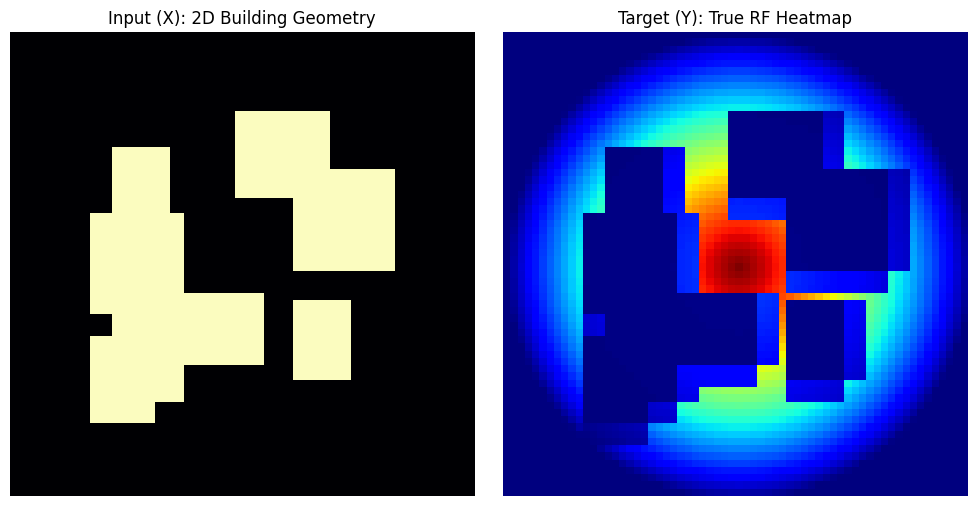

In [3]:
# Cell 3: Synthetic RF Dataset Generator & Visualization
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt

class SyntheticRFDataset(Dataset):
    def __init__(self, num_samples=1000, grid_size=64):
        self.num_samples = num_samples
        self.grid_size = grid_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. INPUT (X): Empty grid for buildings
        buildings = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        
        # Spawn random high-rises
        for _ in range(random.randint(4, 8)):
            w, h = random.randint(8, 16), random.randint(8, 16)
            x, y = random.randint(10, self.grid_size-w-10), random.randint(10, self.grid_size-h-10)
            buildings[y:y+h, x:x+w] = 1.0

        # 2. TARGET (Y): Ground Truth Heatmap (Tower at center 32,32)
        y_coords, x_coords = np.ogrid[:self.grid_size, :self.grid_size]
        dist = np.sqrt((x_coords - 32)**2 + (y_coords - 32)**2) + 1e-5
        
        # Base signal (Free Space Path Loss)
        signal = np.clip(1.0 - (dist / 32.0)**1.2, 0, 1)
        
        # EXTC Physics: Signal crushed inside and immediately behind buildings
        shadow_mask = buildings.copy()
        for i in range(1, 4): 
            shadow_mask += np.roll(buildings, shift=i, axis=1) # Shift shadow right
            shadow_mask += np.roll(buildings, shift=i, axis=0) # Shift shadow down
            
        signal[shadow_mask > 0] *= 0.2   # 80% signal degradation in shadows
        signal[buildings == 1.0] *= 0.05 # 95% degradation inside concrete

        # Add channel dimensions for PyTorch (C, H, W)
        return torch.tensor(buildings).unsqueeze(0), torch.tensor(signal).unsqueeze(0)

# Initialize the Dataset
print("Generating 1,000 Synthetic RF Training Samples...")
train_dataset = SyntheticRFDataset(num_samples=1000)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch one sample to visualize
sample_buildings, sample_heatmap = train_dataset[0]

# Plot the Data Pair
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_buildings[0], cmap='magma')
axes[0].set_title("Input (X): 2D Building Geometry")
axes[0].axis('off')

axes[1].imshow(sample_heatmap[0], cmap='jet')
axes[1].set_title("Target (Y): True RF Heatmap")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Starting Deep Learning Training Phase...
Total Epochs: 10 | Device: cuda
Epoch [1/10] | Training Loss (MSE): 0.023560
Epoch [2/10] | Training Loss (MSE): 0.014786
Epoch [3/10] | Training Loss (MSE): 0.011974
Epoch [4/10] | Training Loss (MSE): 0.011620
Epoch [5/10] | Training Loss (MSE): 0.011536
Epoch [6/10] | Training Loss (MSE): 0.011350
Epoch [7/10] | Training Loss (MSE): 0.011350
Epoch [8/10] | Training Loss (MSE): 0.011151
Epoch [9/10] | Training Loss (MSE): 0.011150
Epoch [10/10] | Training Loss (MSE): 0.011533

Training Complete in 16.35 seconds!


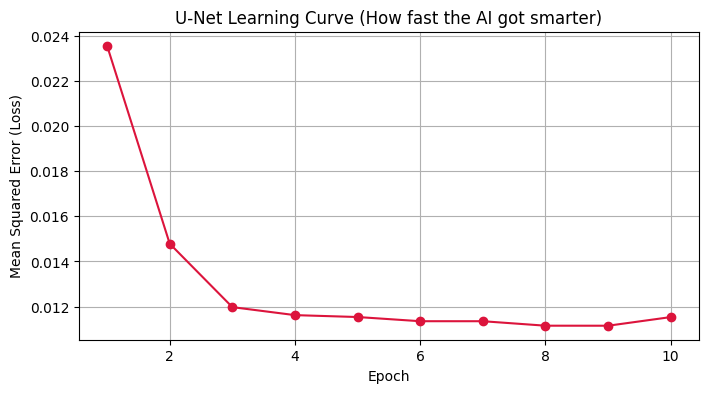

In [5]:
# Cell 4: Training the U-Net (The Learning Phase)
import torch.optim as optim
import torch.nn as nn
import time

# Hyperparameters
EPOCHS = 10
LEARNING_RATE = 0.001

# Loss function and Optimizer
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Starting Deep Learning Training Phase...")
print(f"Total Epochs: {EPOCHS} | Device: {device}")

history_loss = []
start_time = time.time()

# The Training Loop
for epoch in range(EPOCHS):
    model.train() 
    running_loss = 0.0
    
    for i, (inputs, targets) in enumerate(train_loader):
        # --- THE FIX: Force the data into 32-bit Floats ---
        inputs = inputs.to(device).float()
        targets = targets.to(device).float()
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    history_loss.append(epoch_loss)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Training Loss (MSE): {epoch_loss:.6f}")

end_time = time.time()
print(f"\nTraining Complete in {(end_time - start_time):.2f} seconds!")

# Plot the learning curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), history_loss, marker='o', color='crimson')
plt.title("U-Net Learning Curve (How fast the AI got smarter)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Loss)")
plt.grid(True)
plt.show()

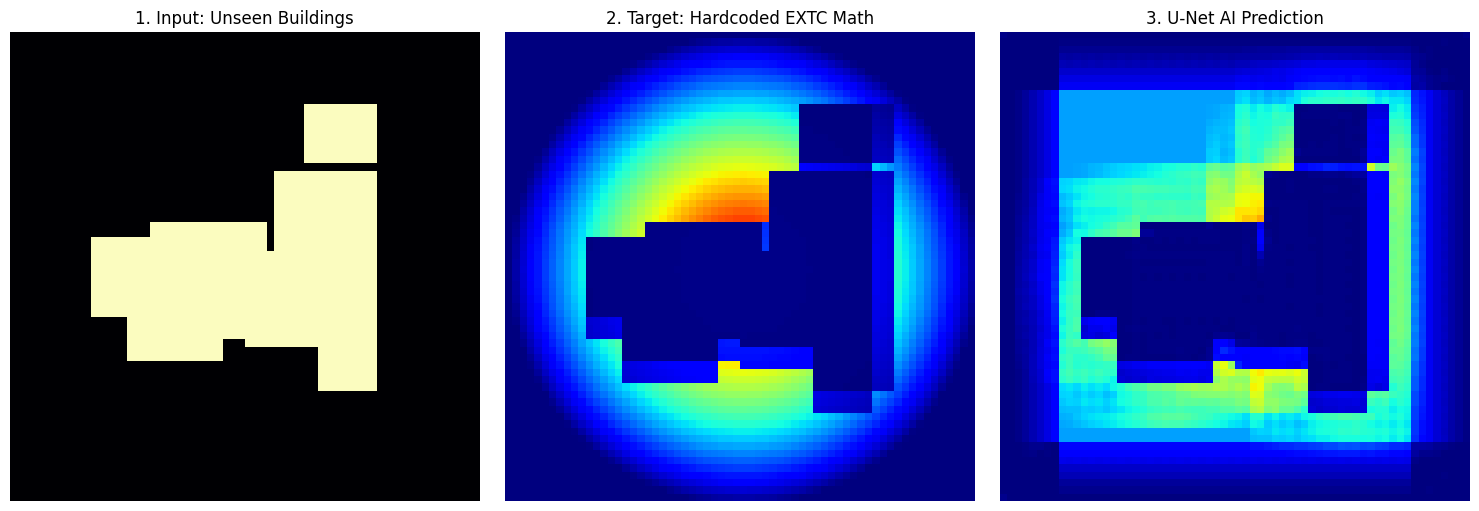

In [6]:
# Cell 5: Live Inference (Testing the AI)
model.eval() # Lock the neural weights (Disable training mode)

with torch.no_grad():
    # 1. Generate a completely unseen test city block
    test_dataset = SyntheticRFDataset(num_samples=1)
    test_input, test_target = test_dataset[0]

    # 2. Send the unseen geometry to the GPU
    test_input_gpu = test_input.unsqueeze(0).to(device).float()

    # 3. Predict! (The AI calculates the heatmap instantly)
    prediction = model(test_input_gpu)

    # Bring the data back to the CPU to plot it
    pred_heatmap = prediction.squeeze().cpu().numpy()
    true_heatmap = test_target.squeeze().numpy()
    bldg_map = test_input.squeeze().numpy()

# Plot the comparison side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bldg_map, cmap='magma')
axes[0].set_title("1. Input: Unseen Buildings")
axes[0].axis('off')

axes[1].imshow(true_heatmap, cmap='jet', vmin=0, vmax=1)
axes[1].set_title("2. Target: Hardcoded EXTC Math")
axes[1].axis('off')

axes[2].imshow(pred_heatmap, cmap='jet', vmin=0, vmax=1)
axes[2].set_title("3. U-Net AI Prediction")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Cell 6: Export the Model for Production
import os

# Save the trained weights to a file
model_name = "rf_vision_unet.pth"
torch.save(model.state_dict(), model_name)
print(f"Model weights saved successfully as: {model_name}")

# If using Colab as the remote kernel, this will trigger the file download to your Windows machine
try:
    from google.colab import files
    files.download(model_name)
    print("Downloading model to your local machine...")
except ImportError:
    print(f"Look in your current folder for '{model_name}' and move it into your local project directory.")

Model weights saved successfully as: rf_vision_unet.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# Cell 7: Secure Model Extraction via Google Drive
from google.colab import drive
import shutil

# 1. Mount your Google Drive to the remote GPU
# This will pop up a prompt asking you to sign in and grant permission.
drive.mount('/content/drive')

# 2. Copy the trained model from the cloud server directly into your Drive
source_file = "rf_vision_unet.pth"
destination_file = "/content/drive/MyDrive/rf_vision_unet.pth"

try:
    shutil.copy(source_file, destination_file)
    print(f"\n[SUCCESS] Model successfully extracted and saved to your Google Drive root folder!")
    print("You can now go to drive.google.com to download it.")
except FileNotFoundError:
    print(f"[ERROR] Could not find {source_file}. Did you run Cell 6 to generate it?")

Mounted at /content/drive

[SUCCESS] Model successfully extracted and saved to your Google Drive root folder!
You can now go to drive.google.com to download it.
